<a href="https://colab.research.google.com/github/mullinskatie7-source/Programming-for-Engineers/blob/main/Katherine_Mullins_OpenChannelDepth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Find Depth of Flow in an Open Channel

**Engineer:** Katherine Mullins

**Completion Date:** 06/22/2026

**Class:** EGN3214

**Assignment #:** 5

**Tool Used:** Colab / Python

## Problem Description

An engineer is designing a warning system for an open trapezoidal channel. The warning system must trigger when the channel flow reaches 50 cfs, but the available measuring system detects water depth rather than flow rate. Therefore, the required depth corresponding to a flow rate of 50 cfs must be determined.

The channel has a 3 ft bottom width, a 2 horizontal to 1 vertical side slope, and a longitudinal slope of 1 ft per 100 ft. Manning’s roughness coefficient for a clean earth channel is used in the calculation. The Manning equation is nonlinear with respect to depth, so the solution requires a numerical root-finding method rather than direct algebraic rearrangement.

## Methodology

function named TrapezoidalQ() was used to calculate the flow rate for any selected depth. The function calculates the flow area, wetted perimeter, hydraulic radius, and Manning flow rate. A second function called flow_difference() was created to subtract the target flow rate from the calculated flow rate. This converted the engineering problem into the root equation (f(y)=Q(y)-50).

The Newton-Raphson method was used to update the estimated depth until the solution converged within 0.001 ft. The update equation used was:

[
y_{new} = y - \frac{f(y)}{f'(y)}
]

The derivative was estimated numerically using a centered finite-difference method. Each iteration displayed the current depth estimate, function value, and derivative so the convergence behavior could be observed.



Check at y = 1.0 ft: Q = 25.108 cfs
Newton-Raphson Iterations
--------------------------------------------------------------
Iteration   Depth y (ft)    f(y)            f'(y)           
1           1.500000        6.165807        76.360959       
2           1.419254        0.193354        71.589759       
3           1.416554        0.000213        71.432037       

Required trigger depth: 1.417 ft
Flow at calculated depth: 50.000 cfs
Manual Newton-Raphson: 1.417 ft
SciPy newton():       1.417 ft
SciPy brentq():       1.416 ft


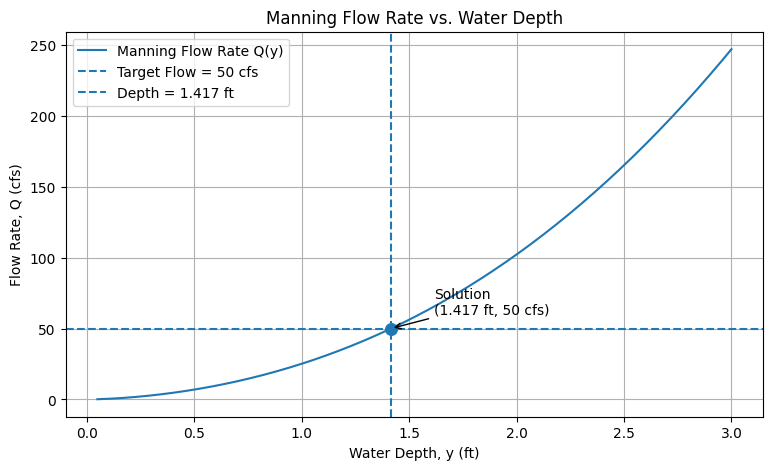

In [6]:
# Step 2: Import required modules and define constants
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton, brentq

# Given channel values
Q_target = 50.0       # cfs
n = 0.0227            # chosen to match the instructor hint near 25.1 cfs at y = 1 ft
b = 3.0               # ft
z = 2.0               # horizontal : vertical side slope
s = 1 / 100           # ft/ft = 0.01

# Step 3: Manning Equation Function

def TrapezoidalQ(n, b, y, z, s):
    """
    Calculates Manning flow rate for a trapezoidal channel.

    n = Manning roughness coefficient
    b = bottom width in ft
    y = water depth in ft
    z = side slope, horizontal to vertical
    s = channel slope in ft/ft

    Returns:
    Q = flow rate in cfs
    """
    A = b * y + z * y * y
    W = b + 2 * y * np.sqrt(1 + z * z)
    R = A / W

    Q = (1.49 / n) * A * np.power(R, 2.0 / 3.0) * np.sqrt(s)

    return Q


print(f"Check at y = 1.0 ft: Q = {TrapezoidalQ(n, b, 1.0, z, s):.3f} cfs")

# Step 4: Reformulate to where f(y)=0
def flow_difference(y, Q_target, n, b, z, s):
    """Root function: f(y) = calculated flow - target flow."""
    return TrapezoidalQ(n, b, y, z, s) - Q_target

# Step 5: Newton-Raphson Numerical Derivative f'(y)
def numerical_derivative(y, Q_target, n, b, z, s, h=1e-6):
    """
    Uses a centered finite-difference approximation for f'(y).
    """
    f_forward = flow_difference(y + h, Q_target, n, b, z, s)
    f_backward = flow_difference(y - h, Q_target, n, b, z, s)

    return (f_forward - f_backward) / (2 * h)

# Step 6: Newton-Raphson Iterations Solver

def CalculateDepth(Q_target, n, b, z, s):
    """
    Finds channel depth using the Newton-Raphson method.

    Returns:
    depth in feet, accurate to 0.001 ft
    """

    y = 1.5           # initial guess in ft
    tolerance = 0.001
    max_iterations = 50

    print("Newton-Raphson Iterations")
    print("-" * 62)

    print("{:<12}{:<16}{:<16}{:<16}".format(
        "Iteration",
        "Depth y (ft)",
        "f(y)",
        "f'(y)"
    ))

    for iteration in range(1, max_iterations + 1):
        f_y = flow_difference(y, Q_target, n, b, z, s)
        df_y = numerical_derivative(y, Q_target, n, b, z, s)

        print(f"{iteration:<12}{y:<16.6f}{f_y:<16.6f}{df_y:<16.6f}")

        # Prevent division by zero
        if abs(df_y) < 1e-12:
            raise ValueError("Derivative is too small. Newton-Raphson cannot continue.")
        y_new = y - f_y / df_y

        # Stop when depth change is within required 0.001 ft accuracy
        if abs(y_new - y) < tolerance:
            return y_new

        y = y_new

    raise ValueError("Newton-Raphson did not converge within the maximum iterations.")

# Step 7: Read Depth Solution Solver

depth_solution = CalculateDepth(Q_target, n, b, z, s)

print()
print(f"Required trigger depth: {depth_solution:.3f} ft")

check_flow = TrapezoidalQ(n, b, depth_solution, z, s)
print(f"Flow at calculated depth: {check_flow:.3f} cfs")

# Step 8: Compare SciPy Methods

# SciPy Newton-Raphson method
depth_scipy_newton = newton(
    func=flow_difference,
    x0=1.5,
    fprime=numerical_derivative,
    args=(Q_target, n, b, z, s),
    tol=0.001
)

# SciPy Brent's method
depth_brentq = brentq(
    flow_difference,
    0.1,
    3.0,
    args=(Q_target, n, b, z, s),
    xtol=0.001
)

print(f"Manual Newton-Raphson: {depth_solution:.3f} ft")
print(f"SciPy newton():       {depth_scipy_newton:.3f} ft")
print(f"SciPy brentq():       {depth_brentq:.3f} ft")
# Plot 1: Manning Flow Rate vs. Water Depth

depth_values = np.linspace(0.05, 3.0, 200)
flow_values = TrapezoidalQ(n, b, depth_values, z, s)

plt.figure(figsize=(9, 5))

plt.plot(depth_values, flow_values, label="Manning Flow Rate Q(y)")
plt.axhline(Q_target, linestyle="--", label="Target Flow = 50 cfs")
plt.axvline(depth_solution, linestyle="--", label=f"Depth = {depth_solution:.3f} ft")

plt.scatter(depth_solution, Q_target, s=70, zorder=3)
plt.annotate(
    f"Solution\n({depth_solution:.3f} ft, 50 cfs)",
    xy=(depth_solution, Q_target),
    xytext=(depth_solution + 0.2, Q_target + 10),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Water Depth, y (ft)")
plt.ylabel("Flow Rate, Q (cfs)")
plt.title("Manning Flow Rate vs. Water Depth")
plt.grid(True)
plt.legend()

plt.show()